/tmp/ipykernel_40946/1127231834.py:5: DtypeWarning: Columns (38,39,41,43) have mixed types. Specify dtype option on import or set low_memory=False.
  df_abl1 = pd.read_csv("/media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT/ABL1/library_with_predictions.csv")
/tmp/ipykernel_40946/1127231834.py:6: DtypeWarning: Columns (38,39,41,43) have mixed types. Specify dtype option on import or set low_memory=False.
  df_dyrk1a = pd.read_csv("/media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT/DYRK1A/library_with_predictions.csv")
/tmp/ipykernel_40946/1127231834.py:7: DtypeWarning: Columns (38,39,41,43) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ttbk1 = pd.read_csv("/media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT/TTBK1/library_with_predictions.csv")


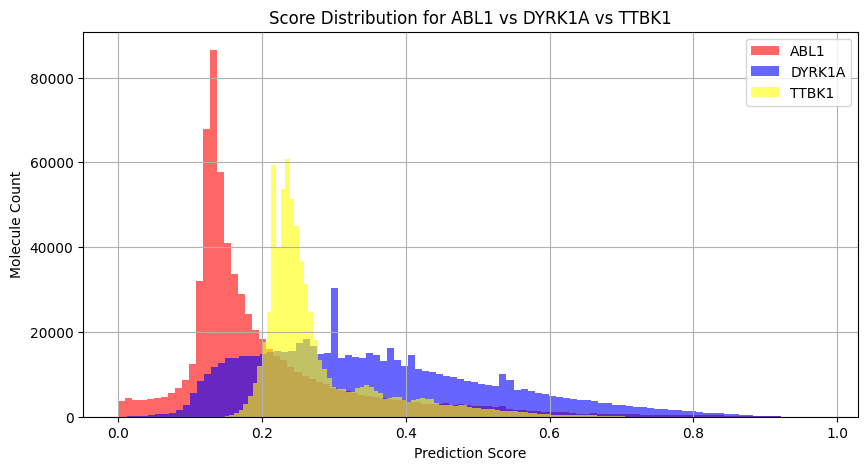

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

# Load prediction results
df_abl1 = pd.read_csv("/media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT/ABL1/library_with_predictions.csv")
df_dyrk1a = pd.read_csv("/media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT/DYRK1A/library_with_predictions.csv")
df_ttbk1 = pd.read_csv("/media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT/TTBK1/library_with_predictions.csv")

plt.figure(figsize=(10,5))

plt.hist(df_abl1["pred_score"], bins=100, alpha=0.6, label="ABL1", color='red')
plt.hist(df_dyrk1a["pred_score"], bins=100, alpha=0.6, label="DYRK1A", color='blue')
plt.hist(df_ttbk1["pred_score"], bins=100, alpha=0.6, label="TTBK1", color='yellow')

plt.xlabel("Prediction Score")
plt.ylabel("Molecule Count")
plt.title("Score Distribution for ABL1 vs DYRK1A vs TTBK1")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# import os
# import pandas as pd
# from functools import reduce

# # Set working directory if needed
# os.chdir("/media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT")

# # Reference compound library (with SMILES & names)
# library_file = "coconut_csv-06-2025.csv"  # Must contain: identifier, smiles, common_name
# library_df = pd.read_csv(library_file)[["identifier", "canonical_smiles", "name"]]

# # Define your input prediction files
# target_files = {
#     "ABL1": "ABL1/library_with_predictions.csv",
#     "DYRK1A": "DYRK1A/library_with_predictions.csv",
#     "TTBK1": "TTBK1/library_with_predictions.csv"
# }

# # Threshold for multi-target selection
# score_threshold = 0.5

# # Load and rename prediction scores
# dfs = []
# for target, filepath in target_files.items():
#     df = pd.read_csv(filepath)[["identifier", "pred_score"]].rename(
#         columns={"pred_score": f"pred_score_{target}"}
#     )
#     dfs.append(df)

# # Merge predictions on 'identifier'
# merged_df = reduce(lambda left, right: pd.merge(left, right, on="identifier"), dfs)

# # Filter multi-target hits (pred_score ≥ threshold for all targets)
# condition = (merged_df.filter(like="pred_score_") >= score_threshold).all(axis=1)
# filtered_df = merged_df[condition]

# # Merge with library metadata (smiles, common_name)
# final_df = pd.merge(filtered_df, library_df, on="identifier", how="left")

# # Save final output
# final_df.to_csv("multi_target_hits_with_0.5th_metadata.csv", index=False)
# print(f"✅ Saved {len(final_df)} multi-target hits with SMILES and common names.")


/tmp/ipykernel_89219/1716757684.py:10: DtypeWarning: Columns (38,39,41,43) have mixed types. Specify dtype option on import or set low_memory=False.
  library_df = pd.read_csv(library_file)[["identifier", "canonical_smiles", "name"]]


✅ Saved 4 multi-target hits with SMILES and common names.


In [ ]:
import os
import pandas as pd
from functools import reduce

# ─────────────────────────────────────────────────────────────────────────────
# 1. Setup
# ─────────────────────────────────────────────────────────────────────────────
os.chdir("/media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT")

# Load reference library (must include: identifier, canonical_smiles, name)
library_file = "coconut_csv-06-2025.csv"
library_df = pd.read_csv(library_file, usecols=["identifier", "canonical_smiles", "name"])

# Prediction files and individual thresholds
target_info = {
    "ABL1":   {"file": "fda_arunabh/library_with_predictions.csv",   "threshold": 0.13},
    "DYRK1A": {"file": "fda_arunabh/library_with_predictions.csv", "threshold": 0.67},
    "TTBK1":  {"file": "fda_arunabh/library_with_predictions.csv",  "threshold": 0.26}
}

# ─────────────────────────────────────────────────────────────────────────────
# 2. Load & Merge Scores
# ─────────────────────────────────────────────────────────────────────────────
dfs = []

for target, info in target_info.items():
    path = info["file"]
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing prediction file for {target}: {path}")
    
    df = pd.read_csv(path, usecols=["identifier", "pred_score"])
    df = df.rename(columns={"pred_score": f"pred_score_{target}"})
    dfs.append(df)

# Merge all prediction dataframes on 'identifier'
merged_df = reduce(lambda left, right: pd.merge(left, right, on="identifier"), dfs)

# 3. Apply Per-Target Thresholds

for target, info in target_info.items():
    col = f"pred_score_{target}"
    threshold = info["threshold"]
    merged_df = merged_df[merged_df[col] >= threshold]


# 4. Merge with Library Metadata & Save

final_df = pd.merge(merged_df, library_df, on="identifier", how="left")
final_df.to_csv("multi_target_YoudenJ_with_metadata.csv", index=False)

print(f"✅ Saved {len(final_df)} multi-target hits with SMILES and names.")


✅ Saved 12674 multi-target hits with SMILES and names.


In [ ]:
# final_df["canonical smiles"].to_csv("multi_target_YoudenJ_only smiles.csv", index=False)
final_df[["canonical_smiles", "identifier"]].to_csv("multi_target_hits_remaining.smi", sep=" ", index=False, header=False)


print(final_df[['identifier', 'name']].head())
print("Columns in final_df:", final_df.columns.tolist())


     identifier            name
0  CNP0074467.1    ETHOXARUTINE
1  CNP0074465.1  Estrapronicate
2  CNP0074332.1      EVODENOSON
3  CNP0320834.1       Gimatecan
4  CNP0074586.1     Pegamotecan
Columns in final_df: ['identifier', 'pred_score_ABL1', 'pred_score_DYRK1A', 'pred_score_TTBK1', 'canonical_smiles', 'name']


In [8]:
final_df["name"].isna().sum()


5935